# Building a linear regression model
Simpel model to solve linear regression problem

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

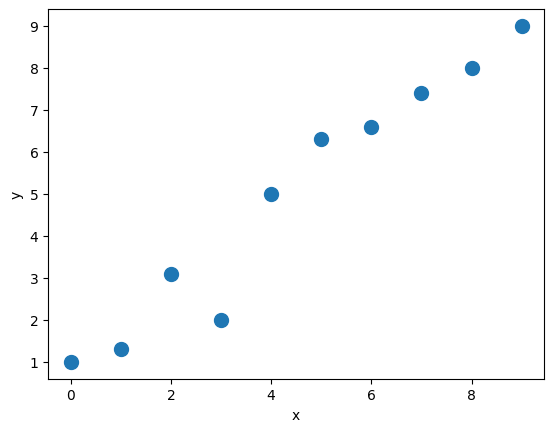

In [16]:
# create a toy dataset in numpy
X_train = np.arange(10).reshape((10,1))
y_train = np.array([1.0, 1.3, 3.1, 2.0, 5.0, 6.3, 6.6, 7.4, 8.0, 9.0])

plt.plot(X_train, y_train, 'o', markersize=10)
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [17]:
# standardize the features (mean centring and dividing by the std.deviation) and create TensorFlow Dataset
X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
ds_train_org = tf.data.Dataset.from_tensor_slices(
    (tf.cast(X_train_norm, tf.float32),
    tf.cast(y_train, tf.float32))
)

In [18]:
# define the model for linear regrisson, z = wx+b
# create class, the consteructor will define w, and b, which correspond to weight and bias parameters

class MyModel(tf.keras.Model):
    def __init__(self):
        super(MyModel, self).__init__()
        self.w = tf.Variable(0.0, name='weight')
        self.b = tf.Variable(0.0, name='bias')

    def call(self, x):
        return self.w * x + self.b

In [19]:
# instantiate a new model from MyModel()
# keras give .summary() which tells us a summaray of the model components layer for layer, and number of parameters
# since we used form tf keras model we can also do that, but we need to define dimensionality first
# can do that by calling model.build() with epxected shape of input data

model = MyModel()
model.build(input_shape=(None, 1))
model.summary()

Model: "my_model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [20]:
# define the cost function, mean squared error
# use stochastic gradinet desect to learn weight paramters
# will use keras to compute gradient instead of manually

def loss_fn(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

def train(model, inputs, outputs, learning_rate):
    with tf.GradientTape() as tape:
        current_loss = loss_fn(model(inputs), outputs)
    dW, db = tape.gradient(current_loss, [model.w, model.b])
    model.w.assign_sub(learning_rate * dW)
    model.b.assign_sub(learning_rate * db)

In [21]:
# now we can se the the hyperparameters and train the model for 200 epochs
# create a batch version of the dataset and repeat dataset with count=None, result in an infinite repated dataset

tf.random.set_seed(1)
num_epochs = 200
log_steps = 100
learning_rate = 0.001
batch_size = 1
steps_per_epochs = int(np.ceil(len(y_train) / batch_size))

ds_train = ds_train_org.shuffle(buffer_size=len(y_train))
ds_train = ds_train.repeat(count=None)
ds_train = ds_train.batch(1)
Ws, bs = [], []

for i, batch in enumerate(ds_train):
    if i >= steps_per_epochs * num_epochs:
        # break the infinite loop
        break
    Ws.append(model.w.numpy())
    bs.append(model.b.numpy())

    bx, by = batch
    loss_val = loss_fn(model(bx), by)

    train(model, bx, by, learning_rate=learning_rate)
    if i%log_steps==0:
        print('Epoch: {:4d} Step: {:2d} Loss {:6.4f}'.format(int(i/steps_per_epochs), i, loss_val))


print('Final paramters: ', model.w.numpy(), model.b.numpy())

Epoch:    0 Step:  0 Loss 43.5600
Epoch:   10 Step: 100 Loss 0.7530
Epoch:   20 Step: 200 Loss 20.1759
Epoch:   30 Step: 300 Loss 23.3976
Epoch:   40 Step: 400 Loss 6.3481
Epoch:   50 Step: 500 Loss 4.6356
Epoch:   60 Step: 600 Loss 0.2411
Epoch:   70 Step: 700 Loss 0.2036
Epoch:   80 Step: 800 Loss 3.8177
Epoch:   90 Step: 900 Loss 0.9416
Epoch:  100 Step: 1000 Loss 0.7035
Epoch:  110 Step: 1100 Loss 0.0348
Epoch:  120 Step: 1200 Loss 0.5404
Epoch:  130 Step: 1300 Loss 0.1170
Epoch:  140 Step: 1400 Loss 0.1195
Epoch:  150 Step: 1500 Loss 0.0944
Epoch:  160 Step: 1600 Loss 0.4670
Epoch:  170 Step: 1700 Loss 2.0695
Epoch:  180 Step: 1800 Loss 0.0020
Epoch:  190 Step: 1900 Loss 0.3612
Final paramters:  2.6576622 4.8798566


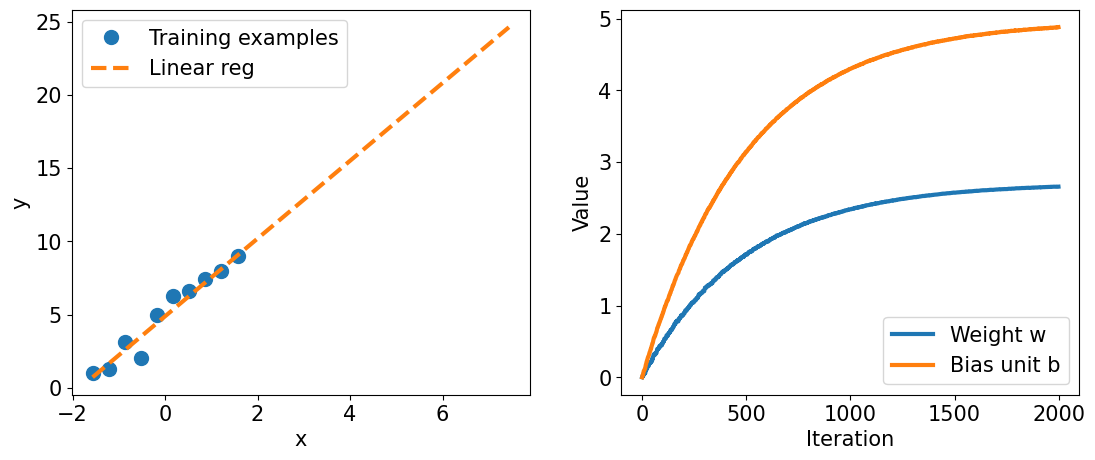

In [22]:
X_test = np.linspace(0,9, num=100).reshape(-1,1)
X_test_norm = (X_test - np.mean(X_train) / np.std(X_train))
y_pred = model(tf.cast(X_test_norm, dtype=tf.float32))

fig = plt.figure(figsize=(13,5))
ax = fig.add_subplot(1,2,1)
plt.plot(X_train_norm, y_train,'o', markersize=10)
plt.plot(X_test_norm, y_pred, '--', lw=3)
plt.legend(['Training examples', 'Linear reg'], fontsize=15)
ax.set_xlabel('x', size=15)
ax.set_ylabel('y', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
ax = fig.add_subplot(1,2,2)
plt.plot(Ws, lw=3)
plt.plot(bs, lw=3)
plt.legend(['Weight w', 'Bias unit b'], fontsize=15)
ax.set_xlabel('Iteration', size=15)
ax.set_ylabel('Value', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.show()

# Model training via the .compile() and .fit() methods
Previously written a manual train and applied stochastic gradient desect optimazitaion
But tensorFlown Keras have a .fit() that can be calles on a instantisated model

In [23]:
tf.random.set_seed(1)
model = MyModel()
model.compile(optimizer='sgd',
                        loss=loss_fn,
                        metrics=['mae', 'mse'])

In [24]:
# now we can call .fit() to simply train it
# we can pass a batched dataset like ds_train, but we can also give NumPy arrays directly without needing to create a dataset
model.fit(X_train_norm, y_train,
          epochs=num_epochs,
          batch_size=batch_size,
          verbose=1)

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 32.4310 - mae: 4.9700 - mse: 32.4310
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 32.4310 - mae: 4.9700 - mse: 32.4310
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 32.4310 - mae: 4.9700 - mse: 32.4310
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 32.4310 - mae: 4.9700 - mse: 32.4310
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 32.4310 - mae: 4.9700 - mse: 32.4310
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 32.4310 - mae: 4.9700 - mse: 32.4310
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 32.4310 - mae: 4.9700 - mse: 32.4310
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 32.4310 - mae: 4.9700 - mse: 32.4310
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 32.4310 - mae: 4.9700 - mse: 32.4310
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 32.4310 - mae: 4.9700 - mse: 32.4310
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━